# **Universidad de Buenos Aires**
# Maestría en Inteligencia Artificial (FIUBA) - Aprendizaje por Refuerzo I
# Tema: Monte Carlo Off-Policy con Importance Sampling (MCIS) en FrozenLake
---
# Trabajo Práctico 1

De acuerdo a la siguiente celda:
1. Resolver y responder las preguntas modificando el código original y reescribiéndolo luego de cada pregunta.
2. **Ejecutar 3 veces** cada celda modificada antes de responder cada pregunta.

Ep 5000 | ε=0.082 | Reward medio (últ. 1k): 0.182


Ep 10000 | ε=0.010 | Reward medio (últ. 1k): 0.271


Ep 15000 | ε=0.010 | Reward medio (últ. 1k): 0.269


Ep 20000 | ε=0.010 | Reward medio (últ. 1k): 0.274


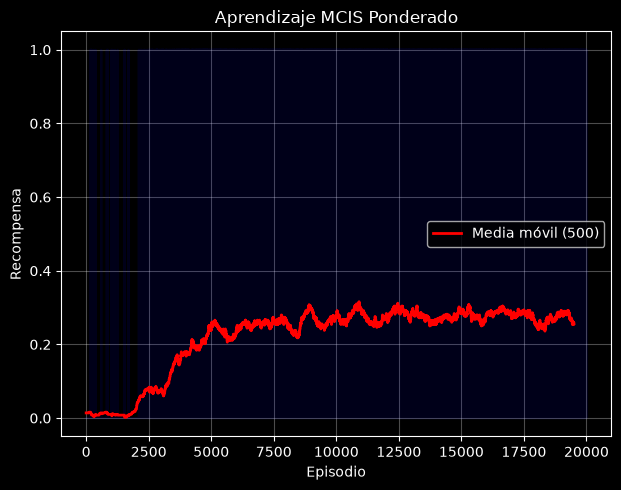


✅ Tasa de éxito de la política aprendida: 27.3%

Política aprendida (← 0, ↓ 1, → 2, ↑ 3):
🤖 ↑ ↓ ← 
← 🕳️ → 🕳️ 
↑ → ← 🕳️ 
🕳️ → → 🎯 


In [1]:
# ============================================================
# 1: Instalación e imports
# ============================================================
!pip install gymnasium matplotlib numpy -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from collections import defaultdict

np.random.seed(42)

# ============================================================
# 2: Entorno y parámetros
# ============================================================
env = gym.make('FrozenLake-v1', is_slippery=True, map_name="4x4")

NUM_EPISODES = 20000
GAMMA = 1.0
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.9995

# ============================================================
# 3: Inicialización
# ============================================================

Q = defaultdict(lambda: np.zeros(env.action_space.n))
C = defaultdict(lambda: np.zeros(env.action_space.n))

def greedy_policy(s):
    return int(np.argmax(Q[s]))

def pi_prob(s, a):
    """π(a|s): 1 si es la acción greedy, 0 si no."""
    return 1.0 if a == greedy_policy(s) else 0.0

def mu_prob(s, a, epsilon):
    """Política de comportamiento (ε-greedy)"""
    nA = env.action_space.n
    if a == greedy_policy(s):
        return 1.0 - epsilon + epsilon / nA
    else:
        return epsilon / nA


# ============================================================
# 4: Generación de episodio
# ============================================================
def generate_episode(epsilon):
    episode = []
    state, _ = env.reset()
    while True:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = greedy_policy(state)

        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))

        if terminated or truncated:
            break
        state = next_state
    return episode

# ============================================================
# 5: Bucle principal MCIS
# ============================================================
rewards_per_episode = []
epsilon = EPSILON_START

for ep in range(NUM_EPISODES):
    episode = generate_episode(epsilon)

    G = 0.0
    W = 1.0

    # Bucle hacia atrás
    for t in range(len(episode) - 1, -1, -1):
        St, At, Rt = episode[t]
        G = GAMMA * G + Rt

        C[St][At] += W
        Q[St][At] += (W / C[St][At]) * (G - Q[St][At])
        W = W * (pi_prob(St, At) / mu_prob(St, At, epsilon))

        if W == 0:
            break

    rewards_per_episode.append(episode[-1][2])
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    if (ep + 1) % 5000 == 0:
        avg_last = np.mean(rewards_per_episode[-1000:])
        print(f"Ep {ep+1} | ε={epsilon:.3f} | Reward medio (últ. 1k): {avg_last:.3f}")

# ============================================================
# 6: Visualización
# ============================================================
def moving_average(x, w=500):
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode, alpha=0.1, color='blue')
plt.plot(moving_average(rewards_per_episode, 500), color='red', linewidth=2, label='Media móvil (500)')
plt.xlabel('Episodio'); plt.ylabel('Recompensa')
plt.title('Aprendizaje MCIS Ponderado')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 7: Evaluación y Política Final
# ============================================================
def evaluate_policy(n_eval=1000):
    successes = 0
    for _ in range(n_eval):
        state, _ = env.reset()
        done = False
        while not done:
            action = greedy_policy(state) # Evaluación 100% Greedy
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            if terminated and reward == 1.0:
                successes += 1
                break
    return successes / n_eval

print(f"\n✅ Tasa de éxito de la política aprendida: {evaluate_policy()*100:.1f}%")

ARROWS = {0: '←', 1: '↓', 2: '→', 3: '↑'}
SPECIAL = {0: '🤖', 5: '🕳️', 7: '🕳️', 11: '🕳️', 12: '🕳️', 15: '🎯'}

print("\nPolítica aprendida (← 0, ↓ 1, → 2, ↑ 3):")
for row in range(4):
    line = ""
    for col in range(4):
        s = row * 4 + col
        if s in SPECIAL:
            line += SPECIAL[s] + " "
        else:
            line += ARROWS[greedy_policy(s)] + " "
    print(line)

**1.** ¿Qué ocurre si se inicializa `Q` en un valor diferente a 0? ¿Por qué? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [2]:
# Pregunta 1: inicializamos Q en un valor distinto de 0 y analizamos el efecto.
# Encapsulamos el entrenamiento original en una función para poder reejecutarlo
# variando SOLO el valor inicial de Q (q_init). El resto queda idéntico al base.
#
# "Ejecutar 3 veces": cada configuración se corre con 3 semillas (SEMILLAS) y se
# reportan las 3 tasas y su promedio. Las 3 corridas se lanzan en paralelo para que la
# Pregunta 7 (hasta 700.000 episodios) termine en un tiempo razonable.
#
# Ojo: np.random.seed no alcanza para que una corrida sea reproducible, porque el
# resbalón del hielo (env.reset/env.step) y env.action_space.sample() usan el generador
# propio del entorno. Por eso también se siembra el entorno.

import multiprocessing as mp
import time

SEMILLAS = (42, 43, 44)


def entrenar_mcis(q_init=0.0, num_episodes=NUM_EPISODES, gamma=GAMMA,
                  epsilon_start=EPSILON_START, epsilon_end=EPSILON_END,
                  epsilon_decay=EPSILON_DECAY, seed=42, verbose=True, stats=None):
    """MCIS ponderado (idéntico al base) pero con Q inicializado en q_init.
    stats (opcional): dict donde se acumula cuántos pasos de cada episodio llegan a
    actualizar Q antes de que el corte por W los descarte."""
    np.random.seed(seed)
    env = gym.make('FrozenLake-v1', is_slippery=True, map_name="4x4")
    env.reset(seed=seed)              # dinámica resbaladiza reproducible
    env.action_space.seed(seed)       # exploración reproducible

    Q = defaultdict(lambda: np.full(env.action_space.n, q_init))
    C = defaultdict(lambda: np.zeros(env.action_space.n))

    def greedy_policy(s):
        return int(np.argmax(Q[s]))

    def pi_prob(s, a):
        return 1.0 if a == greedy_policy(s) else 0.0

    def mu_prob(s, a, epsilon):
        nA = env.action_space.n
        if a == greedy_policy(s):
            return 1.0 - epsilon + epsilon / nA
        return epsilon / nA

    def generate_episode(epsilon):
        episode = []
        state, _ = env.reset()
        while True:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = greedy_policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            if terminated or truncated:
                break
            state = next_state
        return episode

    rewards_per_episode = []
    epsilon = epsilon_start
    for ep in range(num_episodes):
        episode = generate_episode(epsilon)
        G, W = 0.0, 1.0
        usados = 0
        for t in range(len(episode) - 1, -1, -1):
            usados += 1
            St, At, Rt = episode[t]
            G = gamma * G + Rt
            C[St][At] += W
            Q[St][At] += (W / C[St][At]) * (G - Q[St][At])
            W = W * (pi_prob(St, At) / mu_prob(St, At, epsilon))
            if W == 0:
                break
        if stats is not None:
            stats["usados"] += usados
            stats["total"] += len(episode)
        rewards_per_episode.append(episode[-1][2])
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

    # Evaluacion 100% greedy
    def evaluate_policy(n_eval=1000):
        successes = 0
        for _ in range(n_eval):
            state, _ = env.reset()
            done = False
            while not done:
                action = greedy_policy(state)
                state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                if terminated and reward == 1.0:
                    successes += 1
                    break
        return successes / n_eval

    tasa = evaluate_policy()
    if verbose:
        print(f"Q_INIT={q_init:>5} | tasa de exito greedy = {tasa*100:.1f}%")
    return tasa


def _una_corrida(trabajo):
    fn, kwargs, seed = trabajo
    return fn(**kwargs, seed=seed, verbose=False)


def tres_corridas(configs, fn=None, etiquetas=None, titulo=None):
    """
    Corre cada configuración (dict de kwargs) con las 3 SEMILLAS, en paralelo, e imprime
    las 3 tasas de éxito y su promedio. Devuelve un array (n_configs, 3) en %.
    """
    fn = fn or entrenar_mcis
    trabajos = [(c.get("fn", fn), {k: v for k, v in c.items() if k != "fn"}, s)
                for c in configs for s in SEMILLAS]
    # Las corridas más largas primero, para repartir mejor la carga entre procesos.
    orden = sorted(range(len(trabajos)),
                   key=lambda i: -trabajos[i][1].get("num_episodes", NUM_EPISODES))
    t0 = time.perf_counter()
    with mp.get_context("fork").Pool(min(8, len(trabajos))) as pool:
        res = pool.map(_una_corrida, [trabajos[i] for i in orden], chunksize=1)
    tasas = np.empty(len(trabajos))
    tasas[orden] = res
    tasas = 100 * tasas.reshape(len(configs), len(SEMILLAS))

    etiquetas = etiquetas or [", ".join(f"{k}={v}" for k, v in c.items() if k != "fn")
                              for c in configs]
    ancho = max(len(e) for e in etiquetas)
    if titulo:
        print(titulo)
    print(f"{'':<{ancho}} | " + " | ".join(f"semilla {s}" for s in SEMILLAS) + " | promedio ± desvío")
    for e, fila in zip(etiquetas, tasas):
        print(f"{e:<{ancho}} | " + " | ".join(f"{t:>9.1f}%" for t in fila)
              + f" | {fila.mean():5.1f}% ± {fila.std():.1f}")
    print(f"({len(trabajos)} corridas en {time.perf_counter() - t0:.0f} s)")
    return tasas


tasas_p1 = tres_corridas([dict(q_init=q0) for q0 in [0.0, 0.5, 1.0, 5.0, -1.0]],
                         titulo="Efecto del valor inicial de Q sobre la tasa de éxito (greedy, 1000 episodios):")

Efecto del valor inicial de Q sobre la tasa de éxito (greedy, 1000 episodios):
            | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío
q_init=0.0  |      69.0% |      12.6% |      42.9% |  41.5% ± 23.0
q_init=0.5  |      18.3% |      12.7% |      12.1% |  14.4% ± 2.8
q_init=1.0  |      25.1% |       6.5% |      51.4% |  27.7% ± 18.4
q_init=5.0  |      25.1% |       6.5% |      51.4% |  27.7% ± 18.4
q_init=-1.0 |       7.5% |      22.0% |       0.0% |   9.8% ± 9.1
(15 corridas en 53 s)


**Respuesta**

| `q_init` | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío |
|---:|---:|---:|---:|---:|
| 0.0 (base) | 69.0% | 12.6% | 42.9% | **41.5% ± 23.0** |
| 0.5 | 18.3% | 12.7% | 12.1% | 14.4% ± 2.8 |
| 1.0 | 25.1% | 6.5% | 51.4% | 27.7% ± 18.4 |
| 5.0 | 25.1% | 6.5% | 51.4% | 27.7% ± 18.4 |
| −1.0 | 7.5% | 22.0% | 0.0% | 9.8% ± 9.1 |

**Por qué el valor inicial se "lava" pero igual cambia el resultado.** La actualización es

$$Q(s,a) \leftarrow Q(s,a) + \frac{W}{C(s,a)}\,\big(G - Q(s,a)\big).$$

La primera vez que se visita un par $(s,a)$ vale $C(s,a)=W$, entonces $W/C=1$ y queda $Q(s,a)=G$: el valor inicial desaparece del estimador en la primera visita. Lo que `q_init` sí cambia es **qué acción elige la greedy mientras hay acciones sin visitar**. Eso modifica a π, a μ y al corte por $W=0$, y por lo tanto qué datos se juntan:

- **`q_init` = 1.0 y 5.0 dan exactamente lo mismo en las 3 semillas.** Los retornos están en $[0,1]$, así que cualquier valor $\ge 1$ es igual de "optimista": una acción sin probar le gana (o empata) a cualquier acción ya visitada, y la secuencia de decisiones es idéntica. Esto confirma que sólo importa el orden relativo, no el valor en sí.
- **Pesimista (`q_init=-1.0`):** cualquier acción visitada ($Q \ge 0$) le gana a las no visitadas, así que la greedy se queda con las primeras acciones que probó y nunca considera las otras. Es la peor en promedio (9.8%).
- **`q_init=0.5`** es optimista frente a las acciones que fallaron ($Q=0$) y pesimista frente a las que llegaron a la meta.

**¿Mejora la tasa de éxito?** No. La base (`q_init=0`) tiene el mejor promedio, y de todos modos las diferencias quedan dentro de la enorme variabilidad entre semillas (desvíos de 18–23 puntos). La misma configuración da 69% con una semilla y 12.6% con otra. Lo que más pesa es la semilla: el camino que la greedy fija al principio y del que después le cuesta salir (ver P5–P7). Como referencia, el óptimo de este mapa con el límite de 100 pasos es **74.4%** (lo calculé por iteración de valores sobre el modelo del entorno, `env.unwrapped.P`). La semilla 42 queda cerca; las otras quedan atrapadas en políticas malas. La celda original, sin sembrar el entorno, dio 27.3% en esta ejecución.

**2.** ¿Qué ocurre si se cambia la política de exploración de π (que actualmente es una política *hard*, greedy) a una política ε-greedy (reemplazar `def pi_prob` por una función `def pi_prob_soft` que sea ε-greedy, y a su vez cambiar `if W == 0.0: break` por `if W < 1e-5: break`)? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [3]:
# Pregunta 2: cambiamos la política objetivo π de "hard" (greedy) a ε-greedy (soft).
# Ahora π(a|s) > 0 para toda acción, así que el ratio π/μ ya no se anula cuando μ toma
# una acción no-greedy y el bucle hacia atrás puede recorrer el episodio completo. Como el
# peso W puede volverse muy chico (pero no exactamente 0), el corte pasa de "W == 0" a
# "W < 1e-5".
#
# Hay que decidir qué ε usa π. Probamos dos variantes:
#   - eps_pi=None: π usa el mismo ε que μ en ese episodio. Entonces π/μ = 1 en todo paso,
#     W queda fijo en 1 y el método pasa a ser Monte Carlo on-policy.
#   - eps_pi=EPSILON_PI: π es ε-greedy con un ε fijo, distinto del ε (que decae) de μ.

EPSILON_PI = 0.1


def entrenar_mcis_soft(eps_pi=None, num_episodes=NUM_EPISODES, gamma=GAMMA,
                       epsilon_start=EPSILON_START, epsilon_end=EPSILON_END,
                       epsilon_decay=EPSILON_DECAY, seed=42, verbose=True, stats=None):
    np.random.seed(seed)
    env = gym.make('FrozenLake-v1', is_slippery=True, map_name="4x4")
    env.reset(seed=seed)
    env.action_space.seed(seed)
    nA = env.action_space.n

    Q = defaultdict(lambda: np.zeros(nA))
    C = defaultdict(lambda: np.zeros(nA))

    def greedy_policy(s):
        return int(np.argmax(Q[s]))

    def pi_prob_soft(s, a, epsilon):
        """π(a|s) ε-greedy: ya no vale 0 para las acciones no-greedy."""
        if a == greedy_policy(s):
            return 1.0 - epsilon + epsilon / nA
        return epsilon / nA

    def mu_prob(s, a, epsilon):
        if a == greedy_policy(s):
            return 1.0 - epsilon + epsilon / nA
        return epsilon / nA

    def generate_episode(epsilon):
        episode = []
        state, _ = env.reset()
        while True:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = greedy_policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            if terminated or truncated:
                break
            state = next_state
        return episode

    epsilon = epsilon_start
    for ep in range(num_episodes):
        episode = generate_episode(epsilon)
        eps_target = epsilon if eps_pi is None else eps_pi
        G, W = 0.0, 1.0
        usados = 0
        for t in range(len(episode) - 1, -1, -1):
            usados += 1
            St, At, Rt = episode[t]
            G = gamma * G + Rt
            C[St][At] += W
            Q[St][At] += (W / C[St][At]) * (G - Q[St][At])
            # ratio con π soft: ya no da 0 exacto, sino un número > 0
            W = W * (pi_prob_soft(St, At, eps_target) / mu_prob(St, At, epsilon))
            if W < 1e-5:      # <-- corte por peso despreciable (antes era W == 0)
                break
        if stats is not None:
            stats["usados"] += usados
            stats["total"] += len(episode)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

    def evaluate_policy(n_eval=1000):
        successes = 0
        for _ in range(n_eval):
            state, _ = env.reset()
            done = False
            while not done:
                action = greedy_policy(state)
                state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                if terminated and reward == 1.0:
                    successes += 1
                    break
        return successes / n_eval

    tasa = evaluate_policy()
    if verbose:
        print(f"pi soft (epsilon-greedy) | tasa de exito greedy = {tasa*100:.1f}%")
    return tasa


variantes_p2 = [
    ("π hard (greedy, base)", dict(fn=entrenar_mcis)),
    ("π soft (ε_π = ε de μ)", dict(fn=entrenar_mcis_soft)),
    (f"π soft (ε_π = {EPSILON_PI} fijo)", dict(fn=entrenar_mcis_soft, eps_pi=EPSILON_PI)),
]
tasas_p2 = tres_corridas([c for _, c in variantes_p2], etiquetas=[n for n, _ in variantes_p2],
                         titulo="π hard vs π soft (tasa de éxito greedy):")

# ¿Qué fracción de cada episodio llega a actualizar Q antes del corte? (semilla 42)
print("\nPasos de cada episodio que se usan en el bucle hacia atrás (semilla 42):")
for nombre, c in variantes_p2:
    st = {"usados": 0, "total": 0}
    kw = {k: v for k, v in c.items() if k != "fn"}
    c["fn"](**kw, seed=42, verbose=False, stats=st)
    print(f"  {nombre:<24}: {100 * st['usados'] / st['total']:5.1f}% de los pasos")

π hard vs π soft (tasa de éxito greedy):
                        | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío
π hard (greedy, base)   |      69.0% |      12.6% |      42.9% |  41.5% ± 23.0
π soft (ε_π = ε de μ)   |      14.2% |      23.5% |      19.6% |  19.1% ± 3.8
π soft (ε_π = 0.1 fijo) |      16.5% |       0.0% |       4.6% |   7.0% ± 7.0
(9 corridas en 33 s)

Pasos de cada episodio que se usan en el bucle hacia atrás (semilla 42):


  π hard (greedy, base)   :  71.9% de los pasos


  π soft (ε_π = ε de μ)   : 100.0% de los pasos


  π soft (ε_π = 0.1 fijo) :  99.2% de los pasos


**Respuesta**

| variante | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío | pasos usados por episodio |
|---|---:|---:|---:|---:|---:|
| π hard (greedy, base) | 69.0% | 12.6% | 42.9% | **41.5% ± 23.0** | 71.9% |
| π soft (ε_π = ε de μ) | 14.2% | 23.5% | 19.6% | 19.1% ± 3.8 | 100.0% |
| π soft (ε_π = 0.1 fijo) | 16.5% | 0.0% | 4.6% | 7.0% ± 7.0 | 99.2% |

**Qué cambia mecánicamente.** Con π *hard*, $\pi(a|s)=0$ para toda acción no-greedy. Recorriendo el episodio hacia atrás, en cuanto μ tomó una acción no-greedy el peso pasa a $W=0$ y el `break` corta: sólo se aprende del sufijo final. Acá se usa el 71.9% de los pasos (los episodios del principio, con ε alto, se cortan enseguida; los del final, con ε=0.01, se usan casi enteros). Con π *soft* el cociente $\pi/\mu$ nunca es 0, así que se recorre el episodio completo (100% y 99.2% de los pasos) y el corte `W < 1e-5` casi nunca actúa.

El resultado depende de qué ε se le da a π, por eso probé dos variantes:

- **ε_π = ε de μ:** en cada paso $\pi/\mu = 1$, así que $W \equiv 1$ y el método deja de ser off-policy: es Monte Carlo on-policy de cada visita. $Q$ estima el valor de la política ε-greedy promediado sobre **toda** la historia, incluidos los primeros episodios casi aleatorios, donde el retorno es casi siempre 0. Los estimadores quedan sesgados hacia abajo y la greedy final es peor en promedio (19.1%), aunque **mucho más estable entre semillas** (±3.8 contra ±23).
- **ε_π = 0.1 fijo:** mientras ε de μ es mayor a 0.1, cada paso greedy multiplica $W$ por hasta $0.925/0.25 \approx 3.7$. Cuando ε de μ cae por debajo de 0.1 (desde el episodio ~4.600), cada paso exploratorio multiplica $W$ por $0.1/0.01 = 10$. Unos pocos episodios con pesos enormes dominan los promedios ponderados, la varianza explota y es la peor variante (7.0%).

**¿Mejora la tasa de éxito?** No. La π soft aprovecha todo el episodio, pero o pierde el carácter off-policy (con el mismo ε) o dispara la varianza del estimador (con ε fijo). La π hard original sigue teniendo el mejor promedio, aunque depende mucho de la semilla.

**3.** ¿Qué ocurre si se reduce el valor de `EPSILON_START`? ¿Qué valor de `EPSILON_START` es más conveniente? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [4]:
# Pregunta 3: barremos distintos valores de EPSILON_START (probabilidad de
# exploración INICIAL de la política de comportamiento μ). entrenar_mcis ya recibe
# epsilon_start como parámetro.

tasas_p3 = tres_corridas([dict(epsilon_start=e) for e in [1.0, 0.5, 0.3, 0.1, 0.01]],
                         titulo="Efecto de EPSILON_START (20.000 episodios, decay 0.9995):")

Efecto de EPSILON_START (20.000 episodios, decay 0.9995):
                   | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío
epsilon_start=1.0  |      69.0% |      12.6% |      42.9% |  41.5% ± 23.0
epsilon_start=0.5  |      17.9% |      50.1% |      10.5% |  26.2% ± 17.2
epsilon_start=0.3  |      11.5% |      17.8% |       0.0% |   9.8% ± 7.4
epsilon_start=0.1  |      73.8% |       0.0% |       0.0% |  24.6% ± 34.8
epsilon_start=0.01 |       0.0% |       0.0% |       0.0% |   0.0% ± 0.0
(15 corridas en 41 s)


**Respuesta**

| `EPSILON_START` | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío |
|---:|---:|---:|---:|---:|
| 1.0 (base) | 69.0% | 12.6% | 42.9% | **41.5% ± 23.0** |
| 0.5 | 17.9% | 50.1% | 10.5% | 26.2% ± 17.2 |
| 0.3 | 11.5% | 17.8% | 0.0% | 9.8% ± 7.4 |
| 0.1 | 73.8% | 0.0% | 0.0% | 24.6% ± 34.8 |
| 0.01 | 0.0% | 0.0% | 0.0% | 0.0% ± 0.0 |

**Qué ocurre al reducirlo.** `EPSILON_START` es la exploración de μ al comienzo. FrozenLake tiene recompensa rara: sólo hay +1 al llegar a la meta. Al principio todo $Q$ vale 0 y `argmax` desempata en la acción 0 (izquierda), así que la greedy inicial es "ir siempre a la izquierda". Con `EPSILON_START=0.01`, μ es casi esa política: el agente casi nunca llega a la meta, no aparece ninguna señal que propagar y la tasa es **0% en las 3 semillas**. Con 0.1 es una lotería: una semilla encontró un buen camino (73.8%) y las otras dos nunca (0%). Además, empezando más bajo, ε llega antes al piso (con 0.1, en ~4.600 episodios), así que queda todavía menos exploración.

**¿Cuál conviene?** **1.0**, el valor original. Tiene el mejor promedio y es el único de los probados que no dio 0% en ninguna semilla. Bajar `EPSILON_START` no mejora la tasa de éxito: la empeora, y vuelve el resultado mucho más dependiente de la suerte.

**4.** ¿Qué sucede si se reduce el valor de `GAMMA`? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [5]:
# Pregunta 4: barremos distintos valores de GAMMA (factor de descuento).
# entrenar_mcis ya recibe gamma como parámetro.

tasas_p4 = tres_corridas([dict(gamma=g) for g in [1.0, 0.99, 0.95, 0.9, 0.5]],
                         titulo="Efecto de GAMMA (20.000 episodios):")

Efecto de GAMMA (20.000 episodios):
           | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío
gamma=1.0  |      69.0% |      12.6% |      42.9% |  41.5% ± 23.0
gamma=0.99 |      23.1% |       3.9% |      10.3% |  12.4% ± 8.0
gamma=0.95 |      67.7% |       3.3% |      39.4% |  36.8% ± 26.4
gamma=0.9  |      59.2% |       3.6% |      25.0% |  29.3% ± 22.9
gamma=0.5  |       5.0% |       5.8% |      32.3% |  14.4% ± 12.7
(15 corridas en 34 s)


**Respuesta**

| `GAMMA` | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío |
|---:|---:|---:|---:|---:|
| 1.0 (base) | 69.0% | 12.6% | 42.9% | **41.5% ± 23.0** |
| 0.99 | 23.1% | 3.9% | 10.3% | 12.4% ± 8.0 |
| 0.95 | 67.7% | 3.3% | 39.4% | 36.8% ± 26.4 |
| 0.9 | 59.2% | 3.6% | 25.0% | 29.3% ± 22.9 |
| 0.5 | 5.0% | 5.8% | 32.3% | 14.4% ± 12.7 |

**Qué hace `GAMMA` acá.** La única recompensa es el +1 de la meta, así que el retorno de un episodio exitoso es $G = \gamma^{d}$, con $d$ los pasos que faltaban para llegar. Con $\gamma = 1$, $G = 1$ sin importar cuánto tardó: el agente maximiza la **probabilidad de llegar**, que es justamente lo que mide la tasa de éxito. Con $\gamma < 1$ se premian los caminos cortos, y en el hielo resbaladizo los caminos cortos pasan más cerca de los agujeros. Con $\gamma$ muy bajo, además, la señal casi desaparece: desde el inicio el camino mínimo son 6 pasos, $0.5^6 \approx 0.016$, y con los resbalones queda todavía menos, así que las acciones quedan casi empatadas.

**¿Mejora la tasa de éxito?** No. Ningún $\gamma < 1$ le gana a $\gamma = 1$ en promedio. La tendencia tampoco es monótona (0.99 queda peor que 0.95): esas diferencias están dentro del ruido entre semillas, que es de ±20 puntos. Lo único que se ve consistente es que 0.5 y 0.99 quedan bajos en 2 de las 3 semillas. Como el episodio siempre termina (meta, agujero o límite de 100 pasos), $\gamma = 1$ está bien definido y es la elección correcta para este objetivo.

**5.** ¿Qué ocurre si se aumenta la cantidad de episodios? (VALOR EJERCICIO 0.4)

In [6]:
# Pregunta 5: aumentamos NUM_EPISODES dejando el resto igual (en particular
# EPSILON_DECAY=0.9995).

# Referencia: con EPSILON_DECAY=0.9995, epsilon pasa de 1.0 a 0.01 en:
n_hasta_fin = int(np.log(EPSILON_END / EPSILON_START) / np.log(EPSILON_DECAY))
print(f"Con EPSILON_DECAY={EPSILON_DECAY}, epsilon llega a {EPSILON_END} "
      f"recién en ~{n_hasta_fin} episodios.\n")

tasas_p5 = tres_corridas([dict(num_episodes=n) for n in [5000, 20000, 50000, 100000]],
                         titulo="Efecto de NUM_EPISODES (mismo EPSILON_DECAY=0.9995):")

Con EPSILON_DECAY=0.9995, epsilon llega a 0.01 recién en ~9208 episodios.



Efecto de NUM_EPISODES (mismo EPSILON_DECAY=0.9995):
                    | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío
num_episodes=5000   |      72.9% |      15.2% |      16.0% |  34.7% ± 27.0
num_episodes=20000  |      69.0% |      12.6% |      42.9% |  41.5% ± 23.0
num_episodes=50000  |      68.3% |      13.3% |      41.3% |  41.0% ± 22.5
num_episodes=100000 |      70.8% |      24.9% |      49.8% |  48.5% ± 18.8
(12 corridas en 122 s)


**Respuesta**

| `NUM_EPISODES` | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío |
|---:|---:|---:|---:|---:|
| 5.000 | 72.9% | 15.2% | 16.0% | 34.7% ± 27.0 |
| 20.000 (base) | 69.0% | 12.6% | 42.9% | 41.5% ± 23.0 |
| 50.000 | 68.3% | 13.3% | 41.3% | 41.0% ± 22.5 |
| 100.000 | 70.8% | 24.9% | 49.8% | **48.5% ± 18.8** |

**Qué ocurre.** La tasa sube poco y con rendimientos decrecientes: +7 puntos de 5.000 a 20.000, nada de 20.000 a 50.000 (41.5% → 41.0%) y +7 a 100.000. Esa mejora viene casi toda de las semillas que estaban mal (43: 13% → 25%; 44: 16% → 50%). La semilla 42 ya estaba cerca del óptimo (74.4%) con 5.000 episodios.

**Por qué satura.** Con `EPSILON_DECAY=0.9995`, ε llega al piso de 0.01 en ~9.208 episodios. Desde ahí μ es casi la greedy y los episodios extra sólo refinan el camino que la greedy ya recorre: aportan poca información nueva. A eso se suma algo propio del **importance sampling ponderado**. El paso de actualización es $W/C(s,a)$, y $C(s,a)$ acumula los pesos de **todos** los episodios anteriores, incluidos los de la fase exploratoria, donde $W$ crece hasta ×4 por paso ($1/\mu(\text{greedy}) = 1/0.25$ con ε=1). A medida que $C$ crece, cada episodio nuevo mueve $Q$ cada vez menos, así que una política que quedó mal al principio se corrige muy lentamente. Más episodios ayudan, pero poco, y la variabilidad entre semillas pesa más que la cantidad de episodios.

**6.** ¿Qué ocurre si se reduce la tasa de decaimiento de ε (`EPSILON_DECAY`) para prolongar la fase de exploración? ¿Mejora la tasa de éxito? (VALOR EJERCICIO 0.4)

In [7]:
# Pregunta 6: la consigna habla de "reducir la tasa de decaimiento para prolongar
# la exploración". OJO con la semántica: como epsilon se actualiza multiplicando
# por EPSILON_DECAY (epsilon *= decay), un decay MÁS CERCA DE 1 hace que epsilon
# caiga MÁS LENTO => prolonga la exploración. Un decay más chico (más lejos de 1)
# la acorta. Mostramos ambas direcciones y en qué episodio epsilon toca el piso.

def episodio_piso(decay, eps0=EPSILON_START, eps_end=EPSILON_END):
    return int(np.log(eps_end / eps0) / np.log(decay))

decays_p6 = [0.999, 0.9995, 0.9998, 0.9999]
tasas_p6 = tres_corridas(
    [dict(epsilon_decay=d) for d in decays_p6],
    etiquetas=[f"decay={d:<6} (ε toca el piso en ~{episodio_piso(d):>5} ep.)" for d in decays_p6],
    titulo=f"Efecto de EPSILON_DECAY con NUM_EPISODES={NUM_EPISODES}:",
)

Efecto de EPSILON_DECAY con NUM_EPISODES=20000:
                                            | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío
decay=0.999  (ε toca el piso en ~ 4602 ep.) |       6.7% |      30.4% |      16.0% |  17.7% ± 9.7
decay=0.9995 (ε toca el piso en ~ 9208 ep.) |      69.0% |      12.6% |      42.9% |  41.5% ± 23.0
decay=0.9998 (ε toca el piso en ~23023 ep.) |       0.0% |      16.6% |       0.0% |   5.5% ± 7.8
decay=0.9999 (ε toca el piso en ~46049 ep.) |      10.3% |       0.0% |      20.3% |  10.2% ± 8.3
(12 corridas en 22 s)


**Respuesta**

**Semántica.** ε se actualiza como `epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)`. Para *prolongar* la exploración hay que acercar `EPSILON_DECAY` a 1 (decaimiento más lento). Un decay más chico la acorta. En la celda se barren las dos direcciones.

| `EPSILON_DECAY` | ε llega al piso en | ε al final (20.000 ep.) | promedio ± desvío (3 semillas) |
|---:|---:|---:|---:|
| 0.999 | ~4.602 ep. | 0.01 | 17.7% ± 9.7 |
| 0.9995 (base) | ~9.208 ep. | 0.01 | **41.5% ± 23.0** |
| 0.9998 | ~23.023 ep. | ≈ 0.018 | 5.5% ± 7.8 |
| 0.9999 | ~46.049 ep. | ≈ 0.135 | 10.2% ± 8.3 |

**¿Mejora la tasa de éxito?** No: prolongar la exploración la **empeora mucho** (de 41.5% a 5.5% y 10.2%). Hay dos razones:

1. **No queda margen para explotar.** Con 0.9998 y 0.9999, ε no llega al piso dentro de los 20.000 episodios (termina en 0.018 y 0.135), así que casi todo el entrenamiento es exploratorio.
2. **El MCIS con π hard aprende mal mientras ε es alto.** Cada acción no-greedy corta el episodio ($W = 0$) y los pasos que coinciden con la greedy reciben peso $1/\mu(\text{greedy})$, hasta ×4 por paso con ε≈1. Esos episodios de la fase exploratoria cargan $C(s,a)$ con pesos grandes, y después el paso $W/C$ de los episodios buenos queda chico.

Acortar la exploración (0.999) también empeora (17.7%): la política se congela antes de haber explorado lo suficiente. Para 20.000 episodios, de los valores probados el mejor es el original, 0.9995.

**7.** ¿Qué valor conviene darle a la tasa de decaimiento si se aumenta la cantidad de episodios a:

- 60000
- 100000
- 300000
- 500000
- 700000

¿Mejora, empeora o se mantiene aproximadamente igual la tasa de éxito? (VALOR EJERCICIO 0.9)

Decay fijo (0.9995) vs decay adaptado a N (ε toca el piso al 80% de N):
                                   | semilla 42 | semilla 43 | semilla 44 | promedio ± desvío
N= 60000 | decay fijo     0.9995   |      68.5% |      26.2% |      41.0% |  45.2% ± 17.5
N= 60000 | decay adaptado 0.999904 |      10.6% |       0.0% |      18.4% |   9.7% ± 7.5
N=100000 | decay fijo     0.9995   |      70.8% |      24.9% |      49.8% |  48.5% ± 18.8
N=100000 | decay adaptado 0.999942 |       3.1% |       8.2% |       6.8% |   6.0% ± 2.2
N=300000 | decay fijo     0.9995   |      66.4% |      23.4% |      51.6% |  47.1% ± 17.8
N=300000 | decay adaptado 0.999981 |       6.2% |       6.4% |      68.4% |  27.0% ± 29.3
N=500000 | decay fijo     0.9995   |      67.8% |      30.8% |      51.3% |  50.0% ± 15.1
N=500000 | decay adaptado 0.999988 |       0.0% |       9.2% |       0.0% |   3.1% ± 4.3
N=700000 | decay fijo     0.9995   |      71.2% |      29.2% |      50.6% |  50.3% ± 17.1
N=700000 | decay adaptado 0

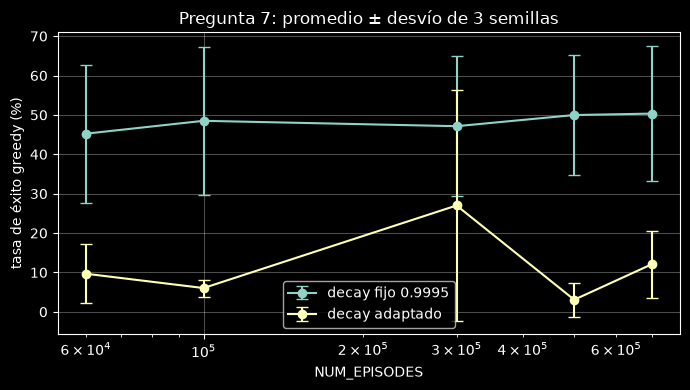

In [8]:
# Pregunta 7: para cada NUM_EPISODES elegimos un EPSILON_DECAY ADAPTADO, en lugar
# de dejar el 0.9995 fijo. La idea (síntesis de P5 y P6): que epsilon recorra de
# EPSILON_START hasta EPSILON_END usando una FRACCIÓN fija del entrenamiento
# (el 80%), dejando el 20% final para explotar la política aprendida.
#
# Si queremos que epsilon toque el piso en el episodio n* = frac * N, entonces:
#     eps_end = eps_start * decay**(n*)   =>   decay = (eps_end/eps_start)**(1/n*)

def decay_para(N, frac=0.8, eps0=EPSILON_START, eps_end=EPSILON_END):
    n_star = max(1, int(frac * N))
    return (eps_end / eps0) ** (1.0 / n_star)

Ns_p7 = [60000, 100000, 300000, 500000, 700000]
configs, etiquetas = [], []
for N in Ns_p7:
    configs += [dict(num_episodes=N, epsilon_decay=0.9995),
                dict(num_episodes=N, epsilon_decay=decay_para(N))]
    etiquetas += [f"N={N:>6} | decay fijo     0.9995",
                  f"N={N:>6} | decay adaptado {decay_para(N):.6f}"]

tasas_p7 = tres_corridas(configs, etiquetas=etiquetas,
                         titulo="Decay fijo (0.9995) vs decay adaptado a N (ε toca el piso al 80% de N):")
fija, adaptada = tasas_p7[0::2], tasas_p7[1::2]

plt.figure(figsize=(7, 4))
for nombre, t in (("decay fijo 0.9995", fija), ("decay adaptado", adaptada)):
    plt.errorbar(Ns_p7, t.mean(axis=1), yerr=t.std(axis=1), marker="o", capsize=4, label=nombre)
plt.xscale("log")
plt.xlabel("NUM_EPISODES"); plt.ylabel("tasa de éxito greedy (%)")
plt.title("Pregunta 7: promedio ± desvío de 3 semillas")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Respuesta**

Comparé, para cada `NUM_EPISODES`, el decay original fijo (0.9995) contra un decay **adaptado** a N, elegido para que ε llegue a 0.01 al 80% del entrenamiento: $\text{decay} = (\varepsilon_{end}/\varepsilon_{start})^{1/(0.8N)}$.

| `NUM_EPISODES` | decay fijo 0.9995 | decay adaptado | decay adaptado: tasa |
|---:|---:|---:|---:|
| 60.000 | **45.2% ± 17.5** | 0.999904 | 9.7% ± 7.5 |
| 100.000 | **48.5% ± 18.8** | 0.999942 | 6.0% ± 2.2 |
| 300.000 | **47.1% ± 17.8** | 0.999981 | 27.0% ± 29.3 |
| 500.000 | **50.0% ± 15.1** | 0.999988 | 3.1% ± 4.3 |
| 700.000 | **50.3% ± 17.1** | 0.999992 | 12.1% ± 8.6 |

(promedio ± desvío de 3 semillas; el detalle por semilla está en la salida de la celda)

**¿Qué valor conviene?** Para este algoritmo, **no estirar el decay en proporción a N**: conviene mantener un decaimiento rápido como **0.9995** (ε llega al piso en ~9.200 episodios) para cualquier N. Esperaba lo contrario: la idea intuitiva es repartir la exploración a lo largo de todo el entrenamiento. Pero el decay adaptado fue mucho peor en las 5 cantidades de episodios (3–27% contra 45–50%). El único resultado bueno (semilla 44 con 300.000 episodios: 68.4%) es la excepción que explica el desvío de ±29.

**¿Mejora, empeora o se mantiene?**
- **Decay fijo 0.9995:** la tasa se mantiene aproximadamente igual, con una leve mejora: 45.2% → 50.3% entre 60.000 y 700.000 episodios. Queda lejos del óptimo de 74.4%, y la variabilidad entre semillas (±15–19 puntos) es mayor que el efecto de multiplicar por 12 los episodios.
- **Decay adaptado:** empeora claramente.

**Por qué el decay adaptado empeora** (MCIS ponderado con π hard):
1. Durante la larga fase con ε alto, casi todo episodio se corta por $W = 0$ apenas aparece una acción no-greedy: se aprende sólo de sufijos cortos y los estados cercanos al inicio casi no se actualizan.
2. Los pasos que coinciden con la greedy reciben pesos de hasta $1/0.25 = 4$ por paso, así que $C(s,a)$ acumula pesos enormes en esa fase, y además estimados bajo políticas greedy que ya cambiaron. Cuando por fin ε baja, los episodios nuevos entran con $W \approx 1$ y el paso $W/C$ es casi 0: $Q$ queda congelado en lo que aprendió explorando al azar. Cuanto más larga la fase exploratoria, peor.

**Conclusión.** En MCIS off-policy con promedio ponderado acumulado, más episodios no se traducen en una mejor política si se estira la exploración, porque el "learning rate" efectivo decae como $1/\sum W$. Para que más episodios sirvan habría que olvidar los pesos viejos, por ejemplo con un paso constante α en lugar de $W/C$, o reiniciando $C$ cuando cambia la greedy. No lo probé porque excede la consigna.